<a href="https://colab.research.google.com/github/ghiaalf/Gen-AI/blob/main/Tugas_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification with NLTK


## Required Packages

In [ ]:
import sys
import nltk
import sklearn
import pandas as pd
import numpy as np

## Version Check

In [ ]:
print('Python: {}'.format(sys.version))
print('NLTK: {}'.format(nltk.__version__))
print('Scikit-learn: {}'.format(sklearn.__version__))
print('Pandas: {}'.format(pd.__version__))
print('NumPy: {}'.format(np.__version__))

Python: 3.7.6 (default, Jan  8 2020, 20:23:39) [MSC v.1916 64 bit (AMD64)]
NLTK: 3.4.5
Scikit-learn: 0.22.1
Pandas: 1.0.1
NumPy: 1.18.1


## Load the dataset


In [ ]:
# Load the dataset of SMS messages
sms = pd.read_table('./dataset/SMSSpamCollection', header=None, encoding='utf-8')
sms.head()

,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
sms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       5572 non-null   object
 1   1       5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
# Check class distribution
sms[0].value_counts()

ham     4825
spam     747
Name: 0, dtype: int64

## Data-preprocess


In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
label = enc.fit_transform(sms[0])
print(label[:10])
print(sms[0][:10])

[0 0 1 0 0 1 0 0 1 1]
0     ham
1     ham
2    spam
3     ham
4     ham
5    spam
6     ham
7     ham
8    spam
9    spam
Name: 0, dtype: object


In [ ]:
text = sms[1]
text[:10]

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
5    FreeMsg Hey there darling it's been 3 week's n...
6    Even my brother is not like to speak with me. ...
7    As per your request 'Melle Melle (Oru Minnamin...
8    WINNER!! As a valued network customer you have...
9    Had your mobile 11 months or more? U R entitle...
Name: 1, dtype: object

In [ ]:
# Use regular expression

# Replace email addresses with 'email'
processed = text.str.replace(r'^.+@[^\.].*\.[a-z]{2,}$', 'emailaddress')

# Replace URLs with 'webaddress'
processed = processed.str.replace(r'^http\://[a-zA-Z0-9\-\.]+\.[a-zA-Z]{2,3}(/\S*)?$', 'webaddress')

# Replace money symbols with 'moneysymb' (£ can by typed with ALT key + 156)
processed = processed.str.replace(r'£|\$', 'moneysymb')

# Replace 10 digit phone numbers (formats include paranthesis, spaces, no spaces, dashes) with 'phonenumber'
processed = processed.str.replace(r'^\(?[\d]{3}\)?[\s-]?[\d]{3}[\s-]?[\d]{4}$', 'phonenumbr')

# Replace numbers with 'numbr'
processed = processed.str.replace(r'\d+(\.\d+)?', 'numbr')

In [ ]:
# Remove punctuation
processed = processed.str.replace(r'[^\w\d\s]', ' ')

# Replace whitespace between terms with a single space
processed = processed.str.replace(r'\s+', ' ')

# Remove leading and trailing whitespace
processed = processed.str.replace(r'^\s+|\s+?$', '')

In [ ]:
processed = processed.str.lower()
processed

0       go until jurong point crazy available only in ...
1                                 ok lar joking wif u oni
2       free entry in numbr a wkly comp to win fa cup ...
3             u dun say so early hor u c already then say
4       nah i don t think he goes to usf he lives arou...
                              ...                        
5567    this is the numbrnd time we have tried numbr c...
5568                  will ü b going to esplanade fr home
5569    pity was in mood for that so any other suggest...
5570    the guy did some bitching but i acted like i d...
5571                            rofl its true to its name
Name: 1, Length: 5572, dtype: object

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

processed = processed.apply(lambda x: ' '.join(term for term in x.split() if term not in stop_words))

In [ ]:
ps = nltk.PorterStemmer()

processed = processed.apply(lambda x: ' '.join(ps.stem(term) for term in x.split()))

In [ ]:
processed

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri numbr wkli comp win fa cup final tk...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    numbrnd time tri numbr contact u u moneysymbnu...
5568                              ü b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: 1, Length: 5572, dtype: object

## Feature extraction


In [ ]:
from nltk.tokenize import word_tokenize

all_words = []

for message in processed:
    words = word_tokenize(message)
    for w in words:
        all_words.append(w)

all_words = nltk.FreqDist(all_words)

# Print the result
print('Number of words: {}'.format(len(all_words)))
print('Most common words: {}'.format(all_words.most_common(15)))

Number of words: 6579
Most common words: [('numbr', 2648), ('u', 1207), ('call', 674), ('go', 456), ('get', 451), ('ur', 391), ('gt', 318), ('lt', 316), ('come', 304), ('moneysymbnumbr', 303), ('ok', 293), ('free', 284), ('day', 276), ('know', 275), ('love', 266)]


In [ ]:
# use the 1500 most common words as features
word_features = [x[0] for x in all_words.most_common(1500)]

In [ ]:
def find_features(message):
    words = word_tokenize(message)
    features = {}
    for word in word_features:
        features[word] = (word in words)

    return features

In [ ]:
features = find_features(processed[0])
for key, value in features.items():
    if value == True:
        print(key)

go
got
n
great
wat
e
world
point
avail
crazi
bugi
la
cine


In [ ]:
list(features.items())[:10]

[('numbr', False),
 ('u', False),
 ('call', False),
 ('go', True),
 ('get', False),
 ('ur', False),
 ('gt', False),
 ('lt', False),
 ('come', False),
 ('moneysymbnumbr', False)]

In [ ]:
messages = list(zip(processed, label))

np.random.seed(1)
np.random.shuffle(messages)

# Call find_features function for each SMS message
feature_set = [(find_features(text), label) for (text, label) in messages]

In [ ]:
from sklearn.model_selection import train_test_split

training, test = train_test_split(feature_set, test_size=0.25, random_state=1)

In [ ]:
print(len(training))
print(len(test))

4179
1393


## Scikit-learn Classifier with NLTK


In [ ]:
from nltk.classify.scikitlearn import SklearnClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

names = ['K Nearest Neighbors', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'SGD Classifier',
         'Naive Bayes', 'Support Vector Classifier']

classifiers = [
    KNeighborsClassifier(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    LogisticRegression(),
    SGDClassifier(max_iter=100),
    MultinomialNB(),
    SVC(kernel='linear')
]

models = zip(names, classifiers)

for name, model in models:
    nltk_model = SklearnClassifier(model)
    nltk_model.train(training)
    accuracy = nltk.classify.accuracy(nltk_model, test)
    print("{} model Accuracy: {}".format(name, accuracy))

K Nearest Neighbors model Accuracy: 0.9454414931801867
Decision Tree model Accuracy: 0.95908111988514
Random Forest model Accuracy: 0.9813352476669059
Logistic Regression model Accuracy: 0.9834888729361091
SGD Classifier model Accuracy: 0.9806173725771715
Naive Bayes model Accuracy: 0.9856424982053122
Support Vector Classifier model Accuracy: 0.9820531227566404


In [ ]:
from sklearn.ensemble import VotingClassifier

# Since VotingClassifier can accept list type of models
models = list(zip(names, classifiers))

nltk_ensemble = SklearnClassifier(VotingClassifier(estimators=models, voting='hard', n_jobs=-1))
nltk_ensemble.train(training)
accuracy = nltk.classify.accuracy(nltk_ensemble, test)
print("Voting Classifier model Accuracy: {}".format(accuracy))

Voting Classifier model Accuracy: 0.9842067480258435


In [ ]:
text_features, labels = zip(*test)
prediction = nltk_ensemble.classify_many(text_features)

In [ ]:
print(classification_report(labels, prediction))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1199
           1       0.98      0.91      0.94       194

    accuracy                           0.98      1393
   macro avg       0.98      0.95      0.97      1393
weighted avg       0.98      0.98      0.98      1393



In [ ]:
pd.DataFrame( confusion_matrix(labels, prediction),
             index=[['actual', 'actual'], ['ham', 'spam']],
             columns = [['predicted', 'predicted'], ['ham', 'spam']])

predicted     
                  ham spam
actual ham       1195    4
       spam        18  176

# RNN Basic


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('Tensorflow: {}'.format(tf.__version__))

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

Tensorflow: 2.3.1


## RNN in Tensorflow
Recurrent Neural Network (RNN for short) is the neural network that has backward stream into input node. Simple notation is expressed like this,

![RNN](image/simpleRNN.png)

And it is implemented in Tensorflow (of course, it can be easily used with tensorflow keras). There are two implementation approaches,

- Using basic cell (`SimpleRNNCell`) and merge it with multiple elements to build complex model like Long Short Term Mermory (LSTM) or Gated Recurrent Unit (GRU)

```python
cell = tf.keras.layers.SimpleRNNCell(units=hidden_size)
rnn = tf.keras.layers.RNN(cell, return_sequences=True, return_state=True)
outputs, states = rnn(X_data)
```

- Using RNN Layer (`SimpleRNN`)

```python
rnn = tf.keras.layers.SimpleRNN(units=hidden_size, return_sequences=True,
                                return_state=True)
outputs, states = rnn(X_data)
```

In [ ]:
h = [1, 0, 0, 0]
e = [0, 1, 0, 0]
l = [0, 0, 1, 0]
o = [0, 0, 0, 1]

In [ ]:
X_data = np.array([[h]], dtype=np.float32)
X_data.shape

(1, 1, 4)

In [ ]:
hidden_size = 2
cell = tf.keras.layers.SimpleRNNCell(units=hidden_size)
rnn = tf.keras.layers.RNN(cell, return_sequences=True, return_state=True)
outputs, states = rnn(X_data)

print("X_data: {}, shape: {}".format(X_data, X_data.shape))
print("output: {}, shape: {}".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]]], shape: (1, 1, 4)
output: [[[-0.6887451  0.2290415]]], shape: (1, 1, 2)
states: [[-0.6887451  0.2290415]], shape: (1, 2)


In [ ]:
rnn_2 = tf.keras.layers.SimpleRNN(units=hidden_size, return_sequences=True, return_state=True)
outputs, states = rnn_2(X_data)

print("X_data: {}, shape: {}".format(X_data, X_data.shape))
print("output: {}, shape: {}".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]]], shape: (1, 1, 4)
output: [[[-0.07527272 -0.67188245]]], shape: (1, 1, 2)
states: [[-0.07527272 -0.67188245]], shape: (1, 2)


In [ ]:
X_data = np.array([[h, e, l, l, o]], dtype=np.float32)
X_data.shape

(1, 5, 4)

Same as before, we can build RNN cell.

In [ ]:
cell = tf.keras.layers.SimpleRNNCell(units=hidden_size)
rnn = tf.keras.layers.RNN(cell, return_sequences=True, return_state=True)
outputs, states = rnn(X_data)

print("X_data: {}, shape: {}\n".format(X_data, X_data.shape))
print("output: {}, shape: {}\n".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]], shape: (1, 5, 4)

output: [[[-0.12052011  0.5526149 ]
  [ 0.4244858   0.65038365]
  [-0.8238987   0.44178498]
  [ 0.00774928  0.73565745]
  [ 0.3128305   0.8846916 ]]], shape: (1, 5, 2)

states: [[0.3128305 0.8846916]], shape: (1, 2)


Output contains each hidden states while input data is processed in RNN cell. So the the last element in output is the same as states, since it is the latest states after process.

## Batching Input
Of course, we can extend the dataset with batch size.

![example2](image/rnn_example2.png)

Suppose that we have 3 batch data as inputs, and our input data is `hello`, `eolll`, and `lleel`. Don't worry about complex shape dataset. All the process is the same as before. All you need to do is to make the input dataset with appropriate shape. So in this case, we need to make (3, 5, 4)-shaped input.



In [ ]:
X_data = np.array([[h, e, l, l, o],
                   [e, o, l, l, l],
                   [l, l, e, e, l]], dtype=np.float32)
X_data.shape

(3, 5, 4)

In [ ]:
cell = tf.keras.layers.SimpleRNNCell(units=hidden_size)
rnn = tf.keras.layers.RNN(cell, return_sequences=True, return_state=True)
outputs, states = rnn(X_data)

print("X_data: {}, shape: {}\n".format(X_data, X_data.shape))
print("output: {}, shape: {}\n".format(outputs, outputs.shape))
print("states: {}, shape: {}".format(states, states.shape))

X_data: [[[1. 0. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]]

 [[0. 1. 0. 0.]
  [0. 0. 0. 1.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 0. 1. 0.]]

 [[0. 0. 1. 0.]
  [0. 0. 1. 0.]
  [0. 1. 0. 0.]
  [0. 1. 0. 0.]
  [0. 0. 1. 0.]]], shape: (3, 5, 4)

output: [[[-0.0886425  -0.35497615]
  [-0.37740785  0.4966906 ]
  [-0.17157763  0.7537353 ]
  [-0.36729524  0.62280154]
  [-0.49442795  0.61391914]]

 [[-0.6217956   0.37030688]
  [-0.330911    0.767418  ]
  [-0.40512574  0.708009  ]
  [-0.36787215  0.7476258 ]
  [-0.39487016  0.72745013]]

 [[ 0.36914107  0.60953295]
  [-0.137596    0.22348596]
  [-0.7504324   0.44638833]
  [-0.86478275  0.77702737]
  [-0.49543512  0.88641524]]], shape: (3, 5, 2)

states: [[-0.49442795  0.61391914]
 [-0.39487016  0.72745013]
 [-0.49543512  0.88641524]], shape: (3, 2)


Mentioned before, output contains each hidden states while processing the input data. Each hidden state affects the next hidden state and so on. Then the last hidden state will be states that outputs from RNN cell.

## Summary
Through this post, we covered simple usage of RNN cell and layers in Tensorflow. We just define the dataset with appropriate format, then the RNN layer can generates hidden states for the output that affects to next state.

# RNN - Many-to-one
> In this post, We will briefly cover the many-to-one type, which is one the common types of Recurrent Neural Network and its implementation in tensorflow.

- toc: true
- badges: true
- comments: true
- author: Chanseok Kang
- categories: [Python, Deep_Learning, Tensorflow-Keras]
- image: images/many-to-one_detail.png

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('Tensorflow: {}'.format(tf.__version__))

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

Tensorflow: 2.3.1


## Various usage of RNN
As we already discussed, RNN is used for sequence data handling. And there are several types of RNN architecture.

![various_rnn](image/various_rnn.png) {% fn 1 %}

In previous [post](https://goodboychan.github.io/chans_jupyter/python/deep_learning/tensorflow-keras/2020/10/26/02-RNN-Basic.html), we take a look **one-to-one** type, which is the basic RNN structure. And next one is **one-to-many** type. For example, if the model gets the fixed format like image as an input, it generates the sequence data. You can see the implementation on image caption application. Another type is **many-to-many** type. It gets sequence data as an inputs, and also generates the sequence data as an output. Common application of many-to-many type is machine translation.

## Many-to-one

**Many-to-one** type, which is our topic in this post, gets an sequence data as an input and generates some informatic data like labels. So we can use it for classification. Suppose that someone defines the sentiment of each sentence, and train the model with many-to-one type. And when the model gets the unseen sentence, then it will predict the intention of sentence, good or bad.

![many-to-one example](image/many-to-one.png)

The detailed explanation is like this.

Suppose we have a sentence, "This movis is good". And we want to classify the sentiment of this sentence. In order to do this, we need to apply tokenization in word level. If this sentensce intends the good sentiment, then word token may contains good words, like "good". So we can classify this sentense to good sentiment.

So if we want to apply it in RNN model, we need to consider the sentence as a word sequence(many), then clssify its label(one). That is process of many-to-one type model.

![many-to-one detail](image/many-to-one_detail.png)

But as you notice, computational model cannot accept the word itself as an input. Instead, it needs to convert with numerical vector. **Embedding** Layer can do this.

So how can we implement this with tensorflow?

## Example - Word sentiment classification

At first, we prepare the dummy data for simple classification. For the simplicity, we defined 1 as a good token, and 0 otherwise.

In [ ]:
words = ['good', 'bad', 'worse', 'so good']
y = [1, 0, 0, 1]

Based on this, we can generate the token dictionary, which is the mapping table for each characters. But before we prepare this, we need to consider one exceptional case, the variation of each sentence length. To train the network, the format (or shape) of input data must be fixed. So we need to add the concept of **padding**. Tensorflow has useful API for padding, `pad_sequences`.

In [ ]:
char_set = ['<pad>'] + sorted(list(set(''.join(words))))
idx2char = {idx:char for idx, char in enumerate(char_set)}
char2idx = {char:idx for idx, char in enumerate(char_set)}

In [ ]:
char_set

['<pad>', ' ', 'a', 'b', 'd', 'e', 'g', 'o', 'r', 's', 'w']

In [ ]:
idx2char

{0: '<pad>',
 1: ' ',
 2: 'a',
 3: 'b',
 4: 'd',
 5: 'e',
 6: 'g',
 7: 'o',
 8: 'r',
 9: 's',
 10: 'w'}

In [ ]:
char2idx

{'<pad>': 0,
 ' ': 1,
 'a': 2,
 'b': 3,
 'd': 4,
 'e': 5,
 'g': 6,
 'o': 7,
 'r': 8,
 's': 9,
 'w': 10}

So as we mentioned before, we need to vectorize each tokens.

In [ ]:
X = list(map(lambda word: [char2idx.get(char) for char in word], words))
X_len = list(map(lambda word: len(word), X))

In [ ]:
X

[[6, 7, 7, 4], [3, 2, 4], [10, 7, 8, 9, 5], [9, 7, 1, 6, 7, 7, 4]]

In [ ]:
X_len

[4, 3, 5, 7]

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Padding the sequence of indices
max_sequence=10

X = pad_sequences(X, maxlen=max_sequence, padding='post', truncating='post')

In [ ]:
X

array([[ 6,  7,  7,  4,  0,  0,  0,  0,  0,  0],
       [ 3,  2,  4,  0,  0,  0,  0,  0,  0,  0],
       [10,  7,  8,  9,  5,  0,  0,  0,  0,  0],
       [ 9,  7,  1,  6,  7,  7,  4,  0,  0,  0]])

In [ ]:
y

[1, 0, 0, 1]

Here, we used `pad_sequences` API with several arguments. First, we defined maximum sequence length to 10. So numerical vector has an maximum length of 10. That is, we just consider 10 characters for sequence. And there are some words that has less than 10 characters. In that case, we filled some 0s for padding. Through argument, we can define the direction of padding, `pre` or `post`.

And of course, it is efficient to use the dataset with generator.

In [ ]:
# Generate data pipeline
train_ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(buffer_size=4).batch(batch_size=2)
print(train_ds)

<BatchDataset shapes: ((None, 10), (None,)), types: (tf.int32, tf.int32)>


After that, we can build many-to-one model with simpleRNN.

In [ ]:
input_dim = len(char2idx)
output_dim = len(char2idx)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=input_dim, output_dim=output_dim,
              mask_zero=True, input_length=max_sequence,
              trainable=False, embeddings_initializer=tf.keras.initializers.random_normal()),
    SimpleRNN(units=10),
    Dense(2)
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 10, 11)            121       
_________________________________________________________________
simple_rnn_1 (SimpleRNN)     (None, 10)                220       
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 22        
Total params: 363
Trainable params: 242
Non-trainable params: 121
_________________________________________________________________


In [ ]:
def loss_fn(model, X, y):
    return tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_true=y,
                                                                          y_pred=model(X),
                                                                          from_logits=True))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
tr_loss_hist = []

for e in range(30):
    avg_tr_loss = 0
    tr_step = 0

    for x_mb, y_mb in train_ds:
        with tf.GradientTape() as tape:
            tr_loss = loss_fn(model, x_mb, y_mb)

        grads = tape.gradient(tr_loss, sources=model.variables)
        optimizer.apply_gradients(grads_and_vars=zip(grads, model.variables))
        avg_tr_loss += tr_loss
        tr_step += 1

    avg_tr_loss /= tr_step
    tr_loss_hist.append(avg_tr_loss)

    if (e + 1) % 5 == 0:
        print('epoch: {:3}, tr_loss: {:3f}'.format(e + 1, avg_tr_loss))

epoch:   5, tr_loss: 0.248861
epoch:  10, tr_loss: 0.018041
epoch:  15, tr_loss: 0.003201
epoch:  20, tr_loss: 0.001664
epoch:  25, tr_loss: 0.001231
epoch:  30, tr_loss: 0.001025


After that, we can check the performance of this simple rnn network

In [ ]:
y_pred = model.predict(X)
y_pred = np.argmax(y_pred, axis=-1)

In [ ]:
print('acc: {:.2%}'.format(np.mean(y_pred == y)))

acc: 100.00%


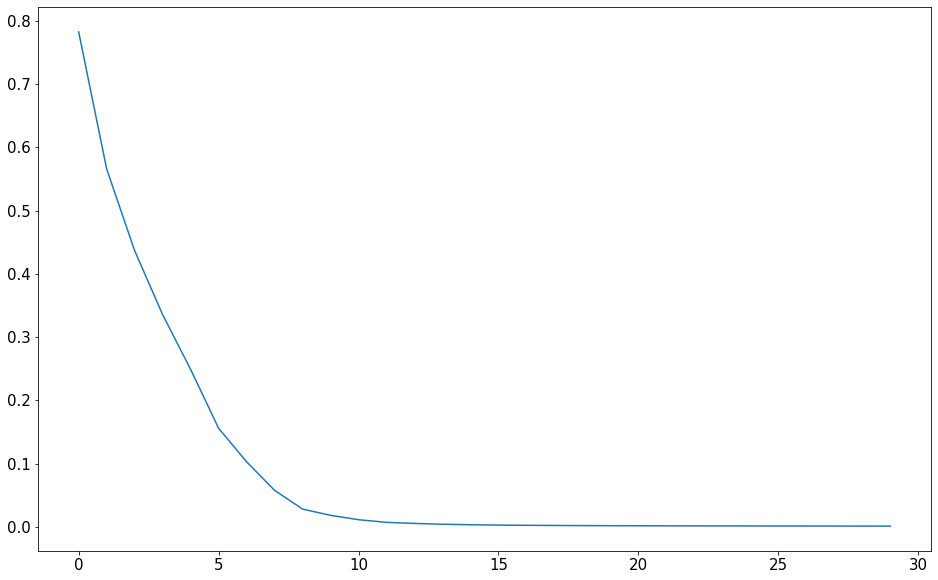

In [ ]:
plt.figure()
plt.plot(tr_loss_hist)
plt.show()

As you can see, the performance of this simple network shows almost 100% accuracy.

## Summary

In this post, we just cover the basic concept of **many-to-one** type RNN model for sentiment classification, and implement it with Tensorflow.

{{ 'Reference from stanford CS231n lecture note' | fndetail: 1 }}

# RNN - Many-to-one stacking
> In this post, We will extend the many-to-one RNN model with stacked version. And it will show the simple implementation in tensorflow.

- toc: true
- badges: true
- comments: true
- author: Chanseok Kang
- categories: [Python, Deep_Learning, Tensorflow-Keras]
- image: images/rnn_many-to-one-stacked_detailed.png

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print('Tensorflow: {}'.format(tf.__version__))

plt.rcParams['figure.figsize'] = (16, 10)
plt.rc('font', size=15)

Tensorflow: 2.3.1


## What is "stacking"

Previously, we covered the many-to-one type RNN model, which can classify the word tokens.

![many-to-one example](image/many-to-one.png) {% fn 1 %}

But what about more complex element, like setence? Of course, same process will be happened. But as you noticed, sometimes the meaning of word in specific sentence is different from meaning of word itself. For example, `not` contains negative meaning, but `not bad` intends positive meaning. Like this, we need to take a different approach in sentence classification.

In order to do this, the complex RNN model is required. More deeper, and more complex. Of course, it is not theoretically clear that has more advanced performance in deep model, but we can easily see the performance improvement in deep model on CNN archiecture. (See the example of AlexNet and VGG19)

![many-to-one stacked](image/rnn_many-to-one-stacked.png) {% fn 2 %}

And here is deeper version of many-to-one that consists of multi-layered RNNs. It is also called **"stacking"** since multi-layered RNN is some kind of stacked RNN layer.

![rnn_many-to-one-stacked_detailed](image/rnn_many-to-one-stacked_detailed.png) {% fn 3 %}

Usually, the hidden layer which close to output layer tends to encode more semantic information. And the hidden layer that close to input layer tends to encode more syntactic information. It means that the hidden layer in input side is concerned with the **amount** of data, and the hidden layer in output side concerned the **meaning** of the data.

## Example - sentence classification

In this example, we will implement stacked RNN model for sentence classification. At first, we prepare the sentence data, and its purpose is to clasify the speaker of sentence. If the sentence is spoken by `richard feynman`, the label will be 1, and if `albert einstein` told the target sentence, the label will be 0.

In [ ]:
sentences = ['What I cannot create, I do not understand',
             'Intellectuals solve problems, geniuses prevent them',
             'A person who never made a mistake never tied anything new.',
             'The same equations have the same solutions']
y = [1, 0, 0, 1]

Same as previous example, we can build token dictionary.

In [ ]:
char_set = ['<pad>'] + sorted(list(set(''.join(sentences))))
idx2char = {idx: char for idx, char in enumerate(char_set)}
char2idx = {char: idx for idx, char in enumerate(char_set)}

Of course, character set will be larger than before.

In [ ]:
char_set

['<pad>',
 ' ',
 ',',
 '.',
 'A',
 'I',
 'T',
 'W',
 'a',
 'b',
 'c',
 'd',
 'e',
 'g',
 'h',
 'i',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'y']

In [ ]:
idx2char

{0: '<pad>',
 1: ' ',
 2: ',',
 3: '.',
 4: 'A',
 5: 'I',
 6: 'T',
 7: 'W',
 8: 'a',
 9: 'b',
 10: 'c',
 11: 'd',
 12: 'e',
 13: 'g',
 14: 'h',
 15: 'i',
 16: 'k',
 17: 'l',
 18: 'm',
 19: 'n',
 20: 'o',
 21: 'p',
 22: 'q',
 23: 'r',
 24: 's',
 25: 't',
 26: 'u',
 27: 'v',
 28: 'w',
 29: 'y'}

In [ ]:
char2idx

{'<pad>': 0,
 ' ': 1,
 ',': 2,
 '.': 3,
 'A': 4,
 'I': 5,
 'T': 6,
 'W': 7,
 'a': 8,
 'b': 9,
 'c': 10,
 'd': 11,
 'e': 12,
 'g': 13,
 'h': 14,
 'i': 15,
 'k': 16,
 'l': 17,
 'm': 18,
 'n': 19,
 'o': 20,
 'p': 21,
 'q': 22,
 'r': 23,
 's': 24,
 't': 25,
 'u': 26,
 'v': 27,
 'w': 28,
 'y': 29}

Based on this mapping, we can build training dataset, same as before.

In [ ]:
X = list(map(lambda sentence: [char2idx.get(char) for char in sentence], sentences))

print(X)

[[7, 14, 8, 25, 1, 5, 1, 10, 8, 19, 19, 20, 25, 1, 10, 23, 12, 8, 25, 12, 2, 1, 5, 1, 11, 20, 1, 19, 20, 25, 1, 26, 19, 11, 12, 23, 24, 25, 8, 19, 11], [5, 19, 25, 12, 17, 17, 12, 10, 25, 26, 8, 17, 24, 1, 24, 20, 17, 27, 12, 1, 21, 23, 20, 9, 17, 12, 18, 24, 2, 1, 13, 12, 19, 15, 26, 24, 12, 24, 1, 21, 23, 12, 27, 12, 19, 25, 1, 25, 14, 12, 18], [4, 1, 21, 12, 23, 24, 20, 19, 1, 28, 14, 20, 1, 19, 12, 27, 12, 23, 1, 18, 8, 11, 12, 1, 8, 1, 18, 15, 24, 25, 8, 16, 12, 1, 19, 12, 27, 12, 23, 1, 25, 15, 12, 11, 1, 8, 19, 29, 25, 14, 15, 19, 13, 1, 19, 12, 28, 3], [6, 14, 12, 1, 24, 8, 18, 12, 1, 12, 22, 26, 8, 25, 15, 20, 19, 24, 1, 14, 8, 27, 12, 1, 25, 14, 12, 1, 24, 8, 18, 12, 1, 24, 20, 17, 26, 25, 15, 20, 19, 24]]


Maybe the length of sentence is different from each other. And it requires padding that fix the format.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_sequence = 55
X = pad_sequences(sequences=X, maxlen=max_sequence, padding='post', truncating='post')

print(X)
print(y)

[[ 7 14  8 25  1  5  1 10  8 19 19 20 25  1 10 23 12  8 25 12  2  1  5  1
  11 20  1 19 20 25  1 26 19 11 12 23 24 25  8 19 11  0  0  0  0  0  0  0
   0  0  0  0  0  0  0]
 [ 5 19 25 12 17 17 12 10 25 26  8 17 24  1 24 20 17 27 12  1 21 23 20  9
  17 12 18 24  2  1 13 12 19 15 26 24 12 24  1 21 23 12 27 12 19 25  1 25
  14 12 18  0  0  0  0]
 [ 4  1 21 12 23 24 20 19  1 28 14 20  1 19 12 27 12 23  1 18  8 11 12  1
   8  1 18 15 24 25  8 16 12  1 19 12 27 12 23  1 25 15 12 11  1  8 19 29
  25 14 15 19 13  1 19]
 [ 6 14 12  1 24  8 18 12  1 12 22 26  8 25 15 20 19 24  1 14  8 27 12  1
  25 14 12  1 24  8 18 12  1 24 20 17 26 25 15 20 19 24  0  0  0  0  0  0
   0  0  0  0  0  0  0]]
[1, 0, 0, 1]


In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(buffer_size=4).batch(batch_size=2)
print(train_ds)

<BatchDataset shapes: ((None, 55), (None,)), types: (tf.int32, tf.int32)>


In order to implement stacked many-to-one model, it is very simple. Just add the hidden layer from 1 to more. And here is new kind of layers, [TimeDistributed](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TimeDistributed). Stacked RNN requires to handle sequence data. So first hidden layer sets the `return_sequences` to `True`. That is, outputs are generated sequentially. And to update the weight related on sequential data, this layer allows to apply a layer to every temporal slice of an input. And `Dropout` is used to avoid overfitting.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, TimeDistributed, Dropout, Dense

input_dim = len(char2idx)
output_dim = len(char2idx)

model = Sequential([
    Embedding(input_dim=input_dim, output_dim=output_dim,
              trainable=False, mask_zero=True, input_length=max_sequence,
              embeddings_initializer=tf.keras.initializers.random_normal()),
    SimpleRNN(units=10, return_sequences=True),
    TimeDistributed(Dropout(rate=0.2)),
    SimpleRNN(units=10),
    Dense(units=2)
])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 55, 30)            900       
_________________________________________________________________
simple_rnn (SimpleRNN)       (None, 55, 10)            410       
_________________________________________________________________
time_distributed (TimeDistri (None, 55, 10)            0         
_________________________________________________________________
simple_rnn_1 (SimpleRNN)     (None, 10)                210       
_________________________________________________________________
dense (Dense)                (None, 2)                 22        
Total params: 1,542
Trainable params: 642
Non-trainable params: 900
_________________________________________________________________


In [ ]:
# Creating loss function
def loss_fn(model, x, y):
    return tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(
        y_true=y, y_pred=model(x), from_logits=True
    ))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
tr_loss_hist = []

for e in range(30):
    avg_tr_loss = 0
    tr_step = 0

    for x_mb, y_mb in train_ds:
        with tf.GradientTape() as tape:
            tr_loss = loss_fn(model, x=x_mb, y=y_mb)
        grads = tape.gradient(target=tr_loss, sources=model.trainable_variables)
        optimizer.apply_gradients(grads_and_vars=zip(grads, model.trainable_variables))
        avg_tr_loss += tr_loss
        tr_step += 1

    avg_tr_loss /= tr_step
    tr_loss_hist.append(avg_tr_loss)

    if (e + 1) % 5 == 0:
        print('epoch: {:3}, tr_loss: {:.3f}'.format(e + 1, avg_tr_loss.numpy()))

epoch:   5, tr_loss: 0.214
epoch:  10, tr_loss: 0.045
epoch:  15, tr_loss: 0.018
epoch:  20, tr_loss: 0.010
epoch:  25, tr_loss: 0.007
epoch:  30, tr_loss: 0.005


After that, train loss is decreased by 0.005. Also we can get almost 100% accuracy.

In [ ]:
prediction = model.predict(X)
prediction = np.argmax(prediction, axis=-1)
print('Accuracy: {:.2%}'.format(np.mean(prediction == y)))

Accuracy: 100.00%


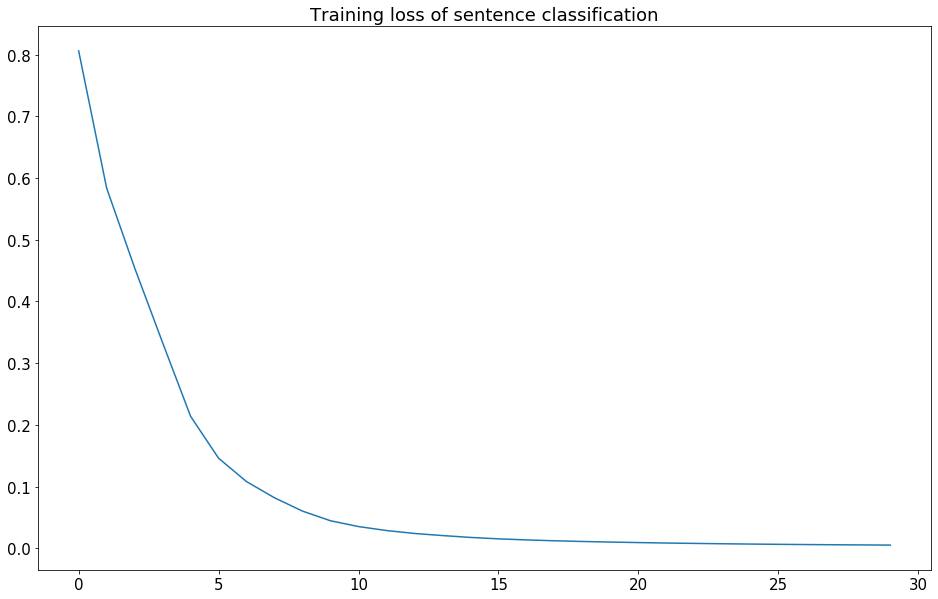

In [ ]:
plt.figure()
plt.plot(tr_loss_hist)
plt.title('Training loss of sentence classification')
plt.show()

## Summary

From two previous post, we cover the many-to-one RNN model. And it is used for word/sentence classification. Especially on sentence classification, more deeper and complex model, namely stacked model, shows the good performance.

{{ 'Reference from stanford CS231n lecture note' | fndetail: 1}}
{{ 'Reference from stanford CS231n lecture note' | fndetail: 2}}
{{ 'Reference from stanford CS231n lecture note' | fndetail: 3}}